In [ ]:
!pip install ultralytics

In [1]:
from PIL import Image
from ultralytics import YOLO
import numpy as np
from utils.dataloader import *
import pprint
import pandas as pd

WARNING ⚠️ torchvision==0.24 is incompatible with torch==2.8.
Run 'pip install torchvision==0.23' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation
Currect path: /orcd/home/002/nath09/6.s058-Project


In [2]:
DATASET_PATH = '/orcd/home/002/nath09/6.s058-Project'
yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
manga_name_list = get_book_list(DATASET_PATH)

In [4]:
m_name = 'Akuhamu'
page_num = 1
f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg'

'/orcd/home/002/nath09/6.s058-Project/Manga109/images/Akuhamu/001.jpg'

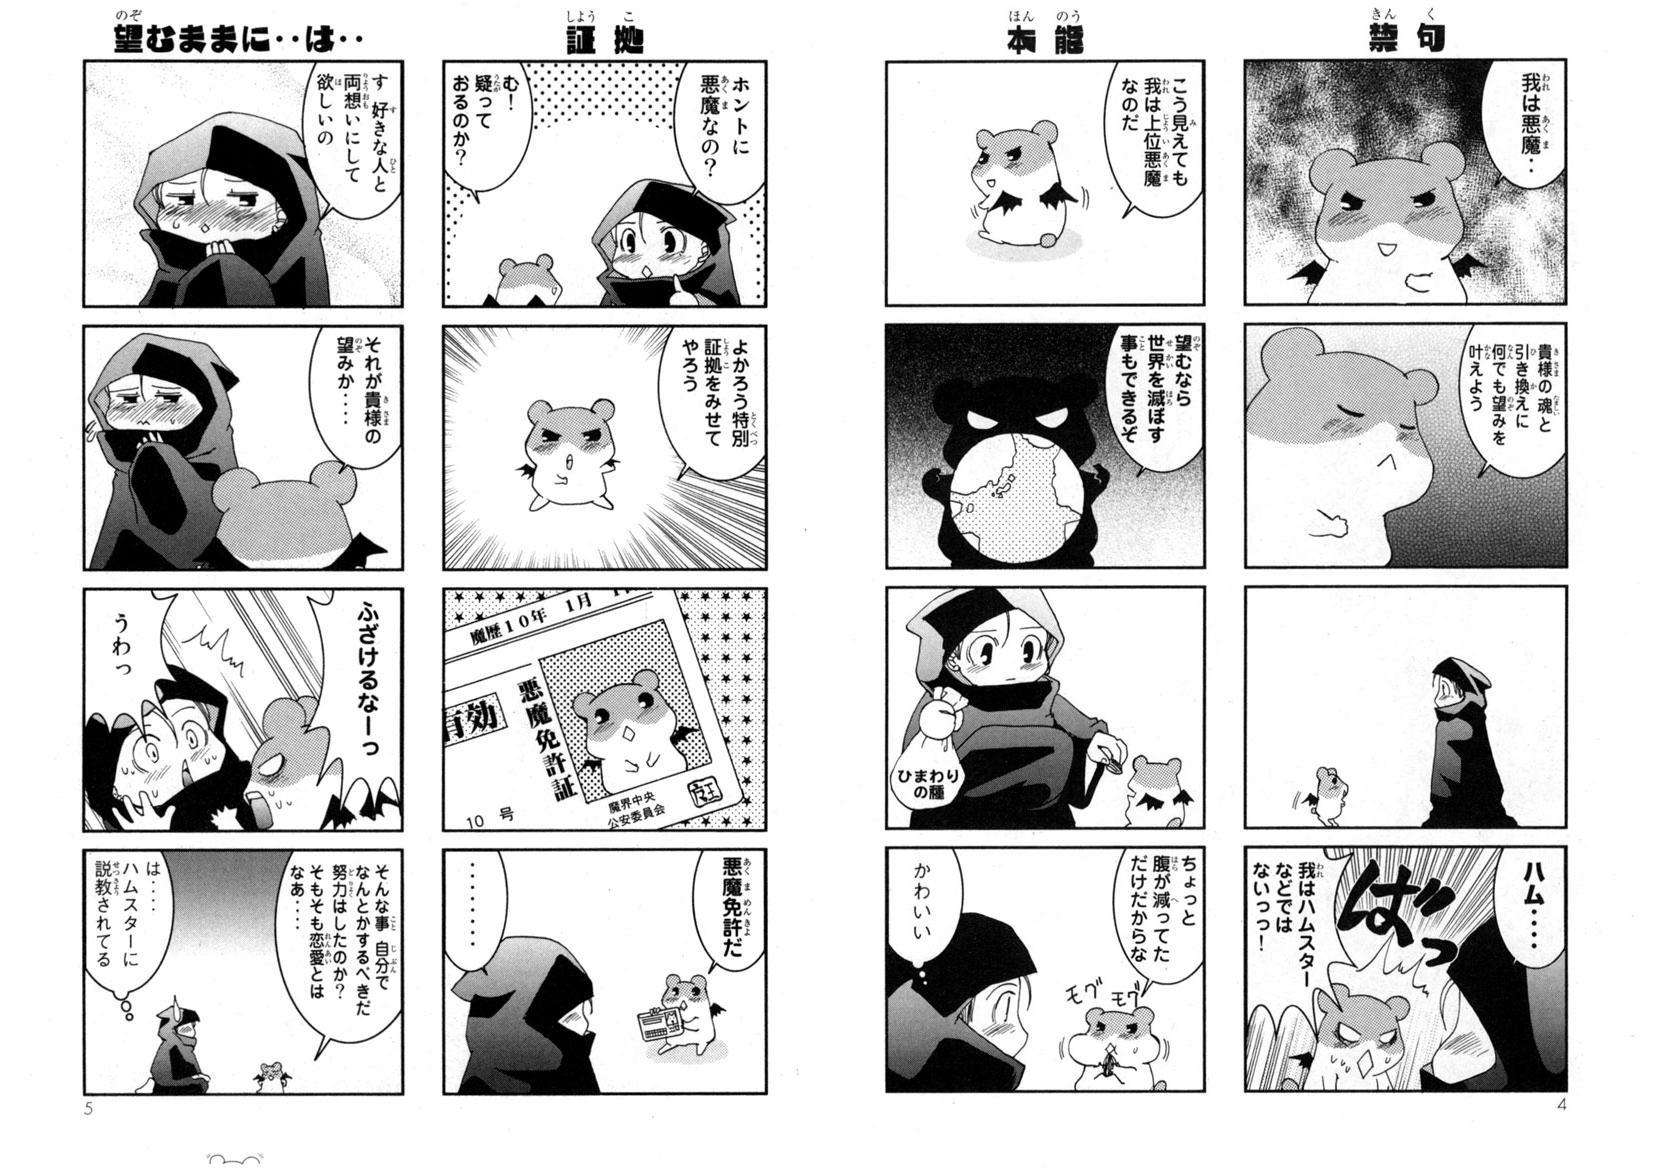

In [5]:
retrieve_page(DATASET_PATH, 'Akuhamu', 2)

In [ ]:
def get_cropped_faces(filenames):
    """
    filenames: list of filename

    Return:
        [[file1_cropped_face1, file1_cropped_face2, ...], [file2_cropped_face1, ...], ...]
    """
    yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
    results = yolov8_animeface.predict(filenames, save=False, conf=0.3, iou=0.5)
    bounding_boxes = get_bounding_boxes(results)
    cropped_faces = []
    for filename, boxes in zip(filenames, bounding_boxes):
        file_cropped_faces = []
        for box in boxes:
            cropped = get_cropped(filename, box)
            file_cropped_faces.append(cropped)
        cropped_faces.append(file_cropped_faces)
    return cropped_faces

# Helper Functions
def get_bounding_boxes(results):
    """
    Input
        results: list of list of detected output
    
    Return
        List of list of dicts
    """
    out = []
    for result in results:
        boxes = result.boxes
        bounding_boxes = []
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
            # confidence = box.conf[0].item()
            
            bound_box = np.array([[x1, y1],
                                  [x2, y2]])
            bounding_boxes.append(bound_box)
        out.append(bounding_boxes)
    return out


def get_cropped(filename, bounding_box):
    """
    Input
        filename: image file name (str)
        top_left: location of top-left corner (len-2 tuple: (x1, y1))
        bottom_right: location of bottom_right corner (len-2 tuple: (x2, y2))
    
    Return
        cropped img
    """
    img = Image.open(filename)

    top_left = bounding_box[0, :]
    bottom_right = bounding_box[1, :]
    # Pillow crop takes (left, upper, right, lower)
    cropped = img.crop((top_left[0], top_left[1], bottom_right[0], bottom_right[1]))
    return cropped

In [ ]:
yolov8_animeface = YOLO('Model/yolov8x6_animeface.pt')
results = yolov8_animeface.predict(f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg', save=True, conf=0.3, iou=0.5)
for result in results:
    boxes = result.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()  # top-left and bottom-right corners
        confidence = box.conf[0].item()
        
        print(f"Face detected:")
        print(f"  Top-left:     ({x1:.1f}, {y1:.1f})")
        print(f"  Bottom-right: ({x2:.1f}, {y2:.1f})")
        print(f"  Width:        {x2 - x1:.1f}px")
        print(f"  Height:       {y2 - y1:.1f}px")
        print(f"  Confidence:   {confidence:.2f}")
        print()

In [ ]:
get_cropped_faces([f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg'])[0][0]

In [ ]:
def compute_iou(box1, box2):
    """
    box1, box2: (xmin, ymin, xmax, ymax)
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


def get_avg_iou(detected_boxes, annotated_boxes, iou_threshold=0.5):
    matched_annotations = set()
    ious = []

    for det in detected_boxes:
        best_iou = 0
        best_idx = -1

        for i, ann in enumerate(annotated_boxes):
            if i in matched_annotations:
                continue
            iou = compute_iou(det, ann)
            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= iou_threshold and best_idx != -1:
            matched_annotations.add(best_idx)
            ious.append(best_iou)

    # penalize missed annotations
    fn = len(annotated_boxes) - len(matched_annotations)
    ious += [0.0] * fn

    return np.mean(ious) if ious else 0.0

In [ ]:
def compute_accuracy(path, manga_name):
    annotations = annotation_loader(path, manga_name)
    ann_pages = get_location(annotations, 'face')

    filenames = []
    ann_boxes = []
    for page_num in ann_pages:
        filenames.append(f'{path}/Manga109/images/{manga_name}/{page_num:03d}.jpg')
        ann_boxes.append([face['position'] for face in ann_pages[page_num]])

    results = yolov8_animeface.predict(filenames, save=False, conf=0.3, iou=0.5)

    page_ious = []
    for result, ann in zip(results, ann_boxes):
        pred_boxes = [box.xyxy[0].tolist() for box in result.boxes]
        iou = get_avg_iou(pred_boxes, ann, iou_threshold=0.5)
        page_ious.append(iou)

    return np.mean(page_ious) if page_ious else 0.0

In [ ]:
ious = []
for manga_name in manga_name_list:
    print(f'Processing {manga_name}...')
    ious.append(compute_accuracy(DATASET_PATH, manga_name))
    print(f'  IoU: {ious[-1]:.4f}')

df = pd.DataFrame({'IOU': ious}, index=manga_name_list)
df.to_csv('YOLO_accuracy.csv', index=True)
print(df)

In [ ]:
compute_accuracy(DATASET_PATH, m_name)

In [12]:
def get_paired_pred_boxes_labels(detected_boxes, annotations, page_num, iou_threshold=0.5):
    annotated_faces = get_location(annotations, 'face')[page_num]
    annotated_boxes = [face['position'] for face in annotated_faces]
    
    # compute all iou pairs
    all_pairs = []
    for det_idx, det in enumerate(detected_boxes):
        for ann_idx, ann in enumerate(annotated_boxes):
            iou = compute_iou(det, ann)
            if iou >= iou_threshold:
                all_pairs.append((iou, det_idx, ann_idx))
    
    # sort by iou descending — greedily match best pairs first
    all_pairs.sort(reverse=True)
    
    matched_dets = set()
    matched_anns = set()
    results = []
    
    for iou, det_idx, ann_idx in all_pairs:
        if det_idx in matched_dets or ann_idx in matched_anns:
            continue
        char_id = annotated_faces[ann_idx]['character']
        results.append((detected_boxes[det_idx], char_id, iou))
        matched_dets.add(det_idx)
        matched_anns.add(ann_idx)
    
    return results